# Chaotic Systems 

- **Part A** : Discrete chaotic systems (Logistic Map, Hénon Map, Bifurcation Diagrams)
- **Part B** : Continuous chaotic systems (Lorenz, Rössler, Chen, Hyperchaotic Rössler)
- **Part C** : Sensitivity Analysis (Parameter Sweep, Step-size Sensitivity)


In [32]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  

plt.rcParams['figure.dpi'] = 100
plt.rcParams['figure.figsize'] = (8, 5)
np.random.seed(0)


---
# Part A  Discrete Chaotic Systems

## A.2 Logistic Map

$$x_{n+1} = r\,x_n(1-x_n)$$

Parameters: $x_0=0.5$, $r=3.9$, 1000 iterations, first 200 discarded as transient.

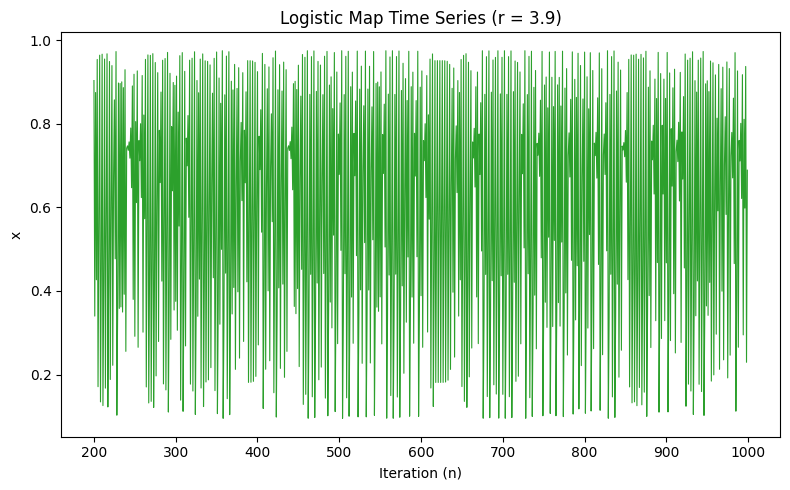

In [47]:
def logistic_map(x0, r, n_iter):
    x = np.empty(n_iter)
    x[0] = x0
    for n in range(n_iter - 1):
        x[n + 1] = r * x[n] * (1 - x[n])
    return x

x0 = 0.5
r = 3.9
n_iter = 1000
transient = 200

x_series = logistic_map(x0, r, n_iter)
x_plot = x_series[transient:]

plt.figure()
plt.plot(range(transient, n_iter), x_plot, lw=0.8, color='tab:green')
plt.xlabel("Iteration (n)")
plt.ylabel("x")
plt.title(f"Logistic Map Time Series (r = {r})")
plt.tight_layout()
plt.show()

**Observation:** After discarding the transient, $x_n$ never settles to a fixed point or a
simple periodic cycle  it jumps irregularly between values in $(0,1)$ for every $n$,
which is the signature of deterministic chaos at $r=3.9$.

## A.3 Hénon Map

$$x_{n+1} = 1 - a x_n^2 + y_n \qquad y_{n+1} = b\,x_n$$

Parameters: $a=1.4$, $b=0.3$, start $(0,0)$, 5000 iterations, first 200 discarded.

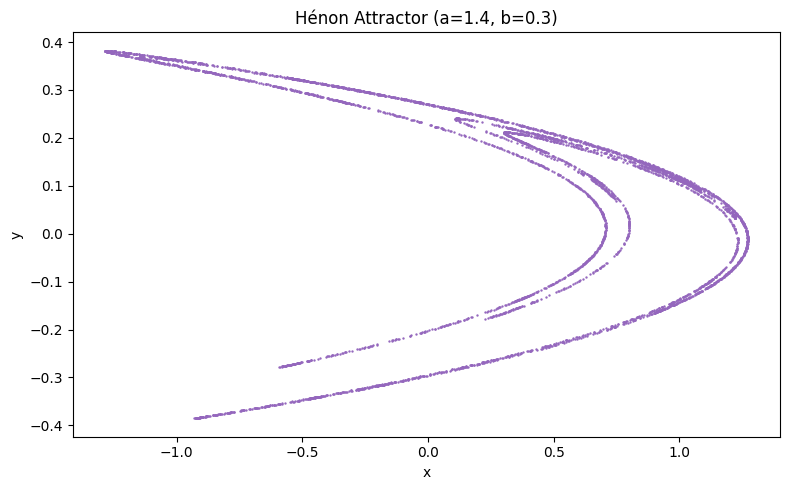

In [16]:
def henon_map(a, b, x0=0.0, y0=0.0, n_iter=5000):
    x = np.empty(n_iter)
    y = np.empty(n_iter)
    x[0], y[0] = x0, y0
    for n in range(n_iter - 1):
        x[n + 1] = 1 - a * x[n]**2 + y[n]
        y[n + 1] = b * x[n]
    return x, y

a_h, b_h = 1.4, 0.3
n_iter_h = 5000
transient_h = 200

hx, hy = henon_map(a_h, b_h, 0.0, 0.0, n_iter_h)
hx_plot, hy_plot = hx[transient_h:], hy[transient_h:]

plt.figure()
plt.scatter(hx_plot, hy_plot, s=0.5, color='tab:purple')
plt.xlabel("x")
plt.ylabel("y")
plt.title(f"Hénon Attractor (a={a_h}, b={b_h})")
plt.tight_layout()
plt.show()

**Observation:** The points do not fill the plane randomly nor collapse onto a simple
curve  they trace a self-similar, fractal-like set (the Hénon attractor), showing the
system is bounded yet never repeats exactly.

## A.4 Bifurcation Diagrams

### Logistic: sweep $r \in [2.5, 4]$, step 0.001

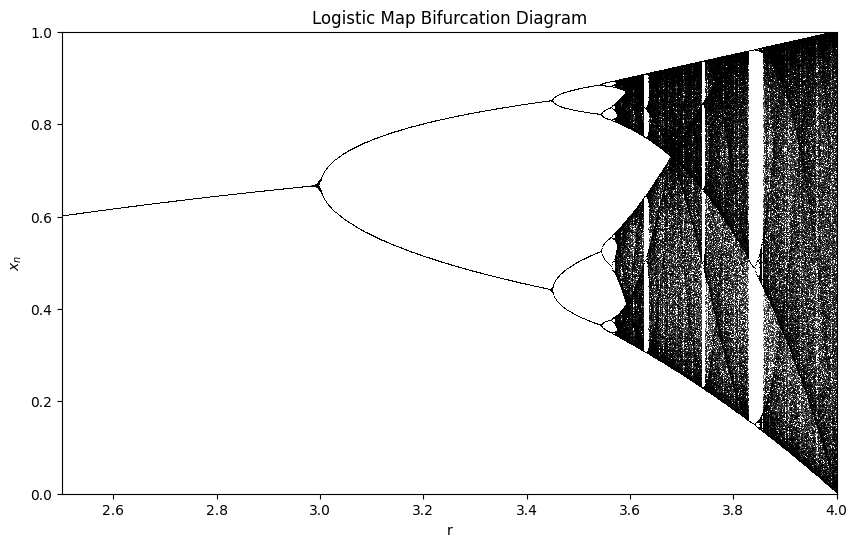

In [37]:
import numpy as np
import matplotlib.pyplot as plt

def logistic_bifurcation(r_min=2.5, r_max=4.0, r_step=0.001,
                          n_iter=1000, n_transient=300, x0=0.5):
    r_range = np.arange(r_min, r_max + r_step, r_step)
    r_vals, x_vals = [], []

    for r in r_range:
        x = x0
        for n in range(n_iter):
            x = r * x * (1 - x)
            if not np.isfinite(x):
                break
            x = min(max(x, 0.0), 1.0)  # guard against float drift
            if n >= n_transient:
                r_vals.append(r)
                x_vals.append(x)

    return np.array(r_vals), np.array(x_vals)

r_vals, x_vals = logistic_bifurcation()

plt.figure(figsize=(10, 6))
plt.plot(r_vals, x_vals, ',k', alpha=0.6, markersize=0.5)
plt.xlabel("r")
plt.ylabel(r"$x_n$")
plt.title("Logistic Map Bifurcation Diagram")
plt.xlim(2.5, 4.0)
plt.ylim(0, 1)
plt.show()

**Explanation:** For low values of r, the system settles into a single stable fixed point, which then splits into two, then four, then eight branches as r increases  a period-doubling cascade. Beyond about r ≈ 3.57 the system becomes chaotic, though narrow white "periodic windows" (like the period-3 window near r ≈ 3.83) still appear where order briefly returns.

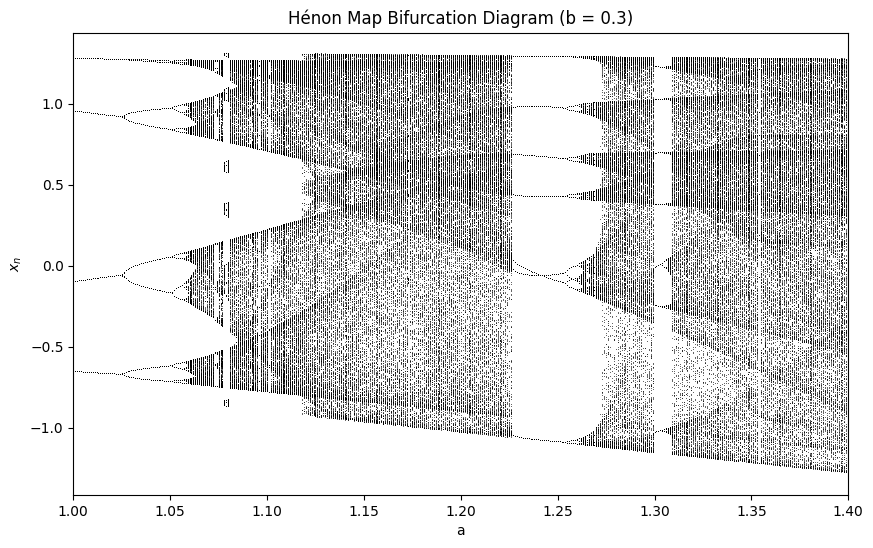

In [38]:
def henon_bifurcation(a_min=1.0, a_max=1.4, a_step=0.001, b=0.3,
                       n_iter=1000, n_transient=300, x0=0.0, y0=0.0):
    a_range = np.arange(a_min, a_max + a_step, a_step)
    a_vals, x_vals = [], []

    for a in a_range:
        x, y = x0, y0
        for n in range(n_iter):
            x_new = 1 - a * x**2 + y
            y_new = b * x
            x, y = x_new, y_new
            if not np.isfinite(x) or abs(x) > 1e3:  # diverging orbit
                break
            if n >= n_transient:
                a_vals.append(a)
                x_vals.append(x)

    return np.array(a_vals), np.array(x_vals)

a_vals, x_vals_h = henon_bifurcation()

plt.figure(figsize=(10, 6))
plt.plot(a_vals, x_vals_h, ',k', alpha=0.6, markersize=0.5)
plt.xlabel("a")
plt.ylabel(r"$x_n$")
plt.title("Hénon Map Bifurcation Diagram (b = 0.3)")
plt.xlim(1.0, 1.4)
plt.show()

**Explanation:** As a increases, the Hénon map's attractor also undergoes period-doubling, splitting into more and more branches before dissolving into chaotic bands. Unlike the logistic map's single chaotic sea, the Hénon diagram shows a fractal, self-similar banded structure, with clear periodic windows (around a ≈ 1.22–1.24) interrupting the chaos.

---
# Part B  Continuous Chaotic Systems


In [33]:
def rk4_integrate(f, state0, t0, t_end, dt, params):
    n_steps = int(round((t_end - t0) / dt))
    t_arr = t0 + np.arange(n_steps + 1) * dt
    state = np.empty((n_steps + 1, len(state0)))
    state[0] = state0
    s = np.array(state0, dtype=float)
    for i in range(n_steps):
        k1 = f(s, params)
        k2 = f(s + 0.5 * dt * k1, params)
        k3 = f(s + 0.5 * dt * k2, params)
        k4 = f(s + dt * k3, params)
        s = s + (dt / 6.0) * (k1 + 2 * k2 + 2 * k3 + k4)
        state[i + 1] = s
    return t_arr, state


## B.2 Lorenz System

$$\dot{x} = \sigma(y-x) \qquad \dot{y} = x(\rho - z) - y \qquad \dot{z} = xy - \beta z$$

| Parameter | Value |
|---|---|
| $\sigma$ | 10 |
| $\rho$ | 28 |
| $\beta$ | 8/3 |
| Initial condition | (1, 1, 1) |
| dt | 0.01 |
| T | 50 |
| Solver | RK4 |

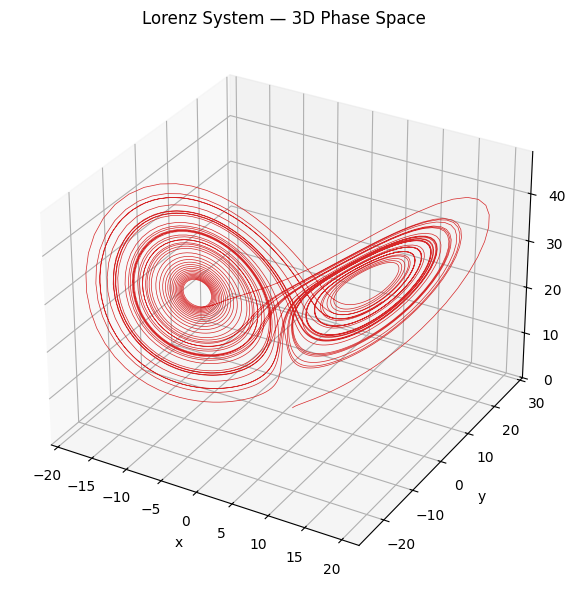

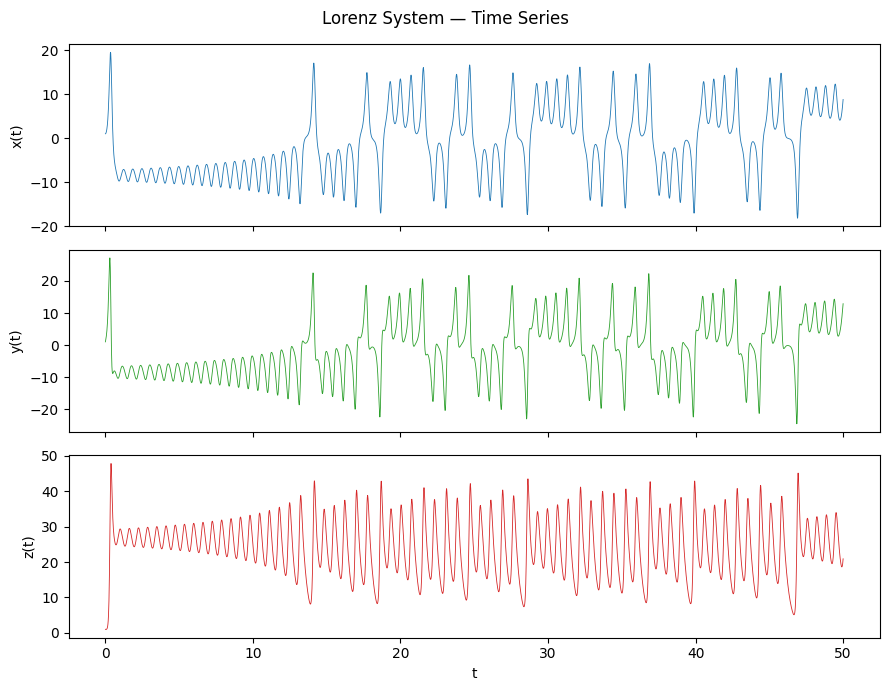

In [20]:
def lorenz_rhs(s, p):
    x, y, z = s
    sigma, rho, beta = p['sigma'], p['rho'], p['beta']
    return np.array([
        sigma * (y - x),
        x * (rho - z) - y,
        x * y - beta * z
    ])

lorenz_params = dict(sigma=10.0, rho=28.0, beta=8.0/3.0)
t_lorenz, state_lorenz = rk4_integrate(lorenz_rhs, [1.0, 1.0, 1.0], 0, 50, 0.01, lorenz_params)
xl, yl, zl = state_lorenz[:, 0], state_lorenz[:, 1], state_lorenz[:, 2]

fig = plt.figure(figsize=(7, 6))
ax = fig.add_subplot(111, projection='3d')
ax.plot(xl, yl, zl, lw=0.5, color='tab:red')
ax.set_xlabel('x'); ax.set_ylabel('y'); ax.set_zlabel('z')
ax.set_title('Lorenz System — 3D Phase Space')
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(3, 1, figsize=(9, 7), sharex=True)
axes[0].plot(t_lorenz, xl, lw=0.6, color='tab:blue'); axes[0].set_ylabel('x(t)')
axes[1].plot(t_lorenz, yl, lw=0.6, color='tab:green'); axes[1].set_ylabel('y(t)')
axes[2].plot(t_lorenz, zl, lw=0.6, color='tab:red'); axes[2].set_ylabel('z(t)')
axes[2].set_xlabel('t')
fig.suptitle('Lorenz System — Time Series')
plt.tight_layout()
plt.show()

## B.3 Rössler System

$$\dot{x} = -y-z \qquad \dot{y} = x + ay \qquad \dot{z} = b + z(x-c)$$

| Parameter | Value |
|---|---|
| $a$ | 0.2 |
| $b$ | 0.2 |
| $c$ | 5.7 |
| Initial condition | (1, 1, 1) |
| dt | 0.01 |
| T | 200 |
| Solver | RK4 |

(T is longer than Lorenz because the Rössler attractor develops its slow spiral-and-fold
structure more gradually.)

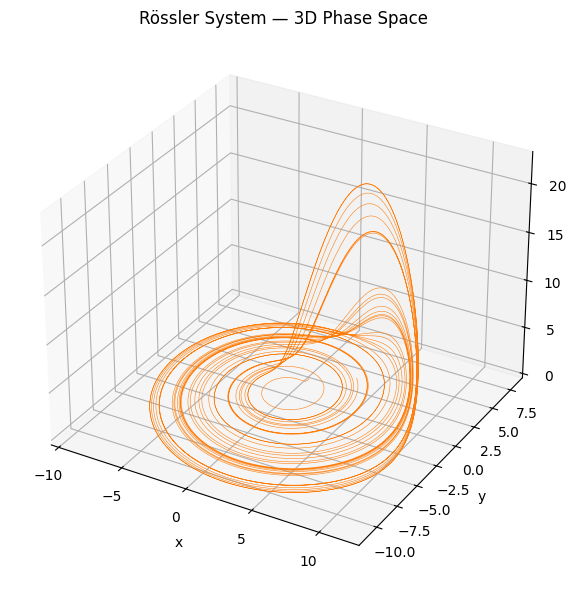

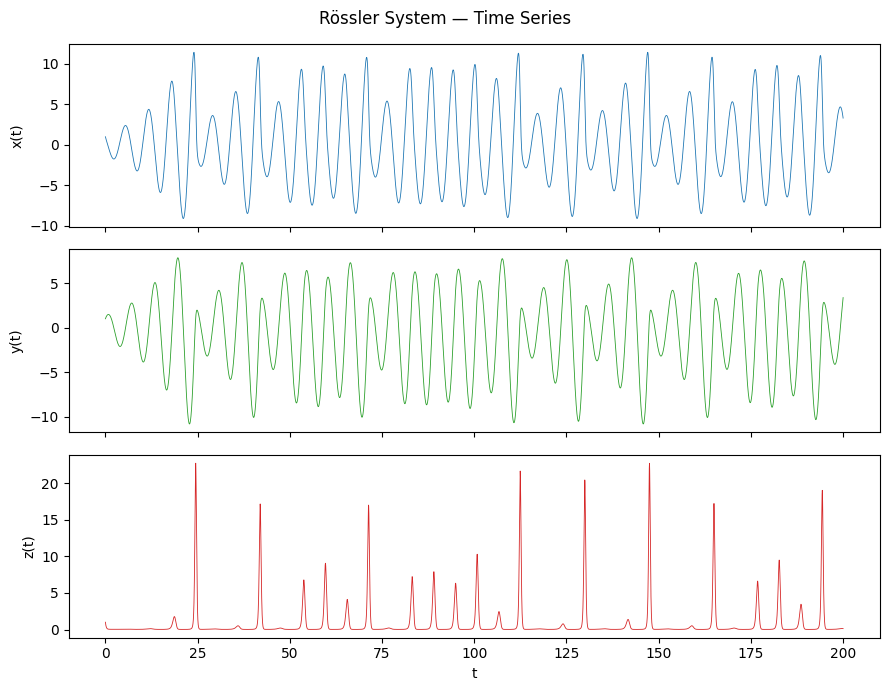

In [21]:
def rossler_rhs(s, p):
    x, y, z = s
    a, b, c = p['a'], p['b'], p['c']
    return np.array([
        -y - z,
        x + a * y,
        b + z * (x - c)
    ])

rossler_params = dict(a=0.2, b=0.2, c=5.7)
t_ros, state_ros = rk4_integrate(rossler_rhs, [1.0, 1.0, 1.0], 0, 200, 0.01, rossler_params)
xr, yr, zr = state_ros[:, 0], state_ros[:, 1], state_ros[:, 2]

fig = plt.figure(figsize=(7, 6))
ax = fig.add_subplot(111, projection='3d')
ax.plot(xr, yr, zr, lw=0.4, color='tab:orange')
ax.set_xlabel('x'); ax.set_ylabel('y'); ax.set_zlabel('z')
ax.set_title('Rössler System — 3D Phase Space')
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(3, 1, figsize=(9, 7), sharex=True)
axes[0].plot(t_ros, xr, lw=0.6, color='tab:blue'); axes[0].set_ylabel('x(t)')
axes[1].plot(t_ros, yr, lw=0.6, color='tab:green'); axes[1].set_ylabel('y(t)')
axes[2].plot(t_ros, zr, lw=0.6, color='tab:red'); axes[2].set_ylabel('z(t)')
axes[2].set_xlabel('t')
fig.suptitle('Rössler System — Time Series')
plt.tight_layout()
plt.show()

## B.4 Chen System

$$\dot{x} = a(y-x) \qquad \dot{y} = (c-a)x - xz + cy \qquad \dot{z} = xy - bz$$

| Parameter | Value |
|---|---|
| $a$ | 35 |
| $b$ | 3 |
| $c$ | 28 |
| Initial condition | (1, 1, 1) |
| dt | 0.002 |
| T | 50 |
| Solver | RK4 |

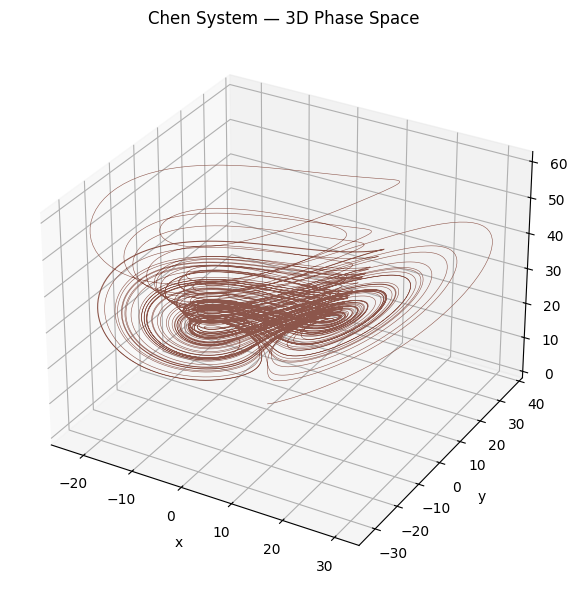

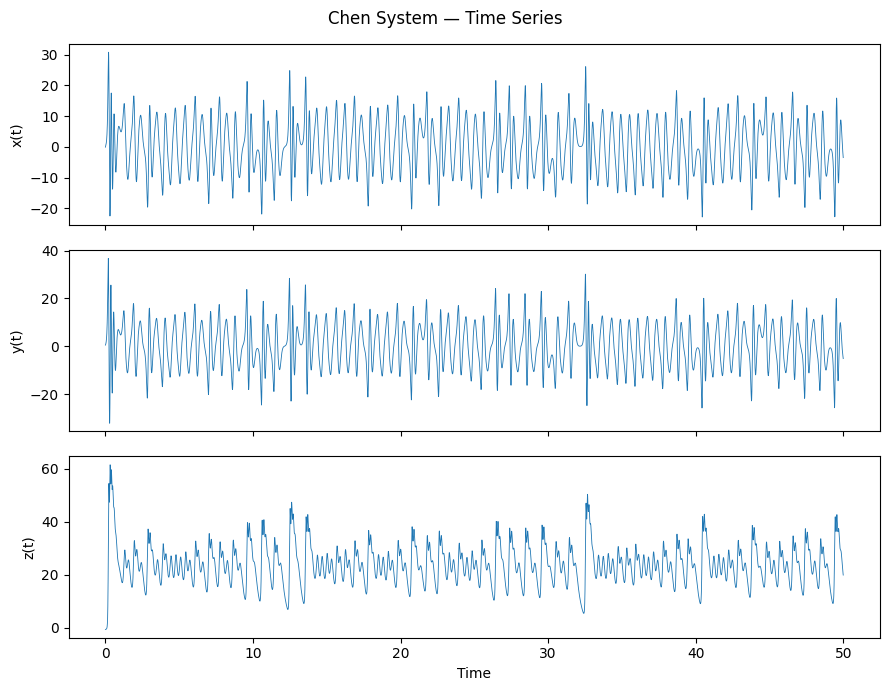

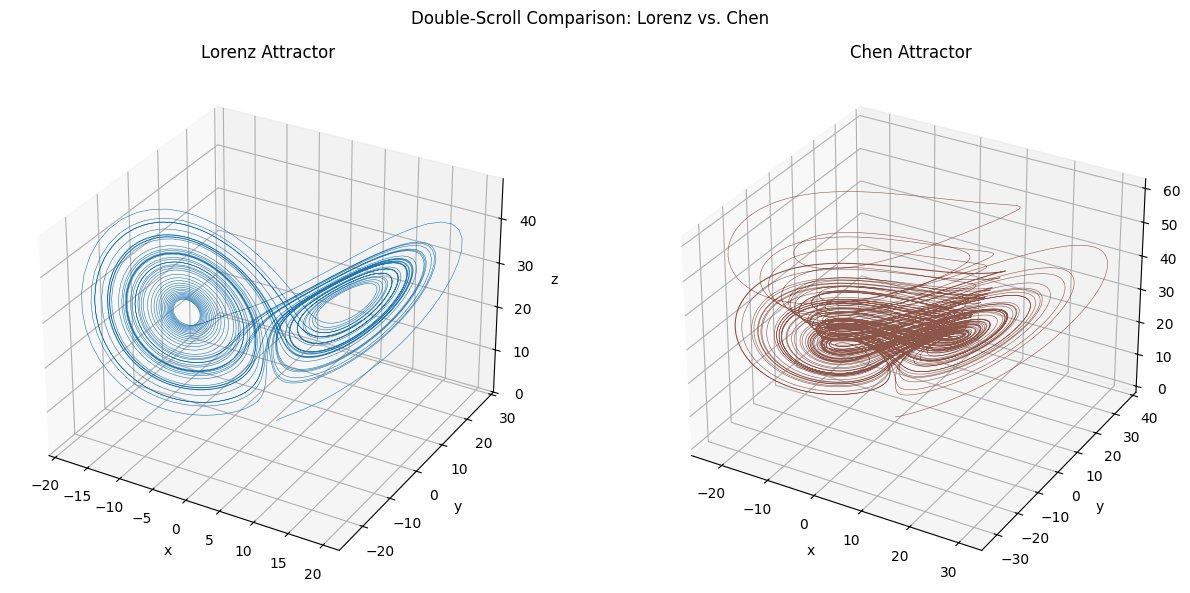

In [40]:
def chen_rhs(s, p):
    x, y, z = s
    a, b, c = p['a'], p['b'], p['c']
    return np.array([
        a * (y - x),
        (c - a) * x - x * z + c * y,
        x * y - b * z
    ])

chen_params = {
    'a': 35.0,
    'b': 3.0,
    'c': 28.0
}

# Initial condition
chen_initial = [-0.1, 0.5, -0.6]
dt_chen = 0.002         
T_chen = 50

t_chen, state_chen = rk4_integrate(
    chen_rhs,
    chen_initial,
    0,
    T_chen,
    dt_chen,
    chen_params
)

xc, yc, zc = state_chen[:, 0], state_chen[:, 1], state_chen[:, 2]

fig = plt.figure(figsize=(7, 6))
ax = fig.add_subplot(111, projection='3d')
ax.plot(xc, yc, zc, lw=0.4, color='tab:brown')
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")
ax.set_title("Chen System — 3D Phase Space")
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(3, 1, figsize=(9, 7), sharex=True)
axes[0].plot(t_chen, xc, lw=0.6)
axes[0].set_ylabel("x(t)")
axes[1].plot(t_chen, yc, lw=0.6)
axes[1].set_ylabel("y(t)")
axes[2].plot(t_chen, zc, lw=0.6)
axes[2].set_ylabel("z(t)")
axes[2].set_xlabel("Time")
fig.suptitle("Chen System — Time Series")
plt.tight_layout()
plt.show()

fig = plt.figure(figsize=(13, 6))

ax1 = fig.add_subplot(121, projection='3d')
ax1.plot(xl, yl, zl, lw=0.4, color='tab:blue')
ax1.set_title("Lorenz Attractor")
ax1.set_xlabel("x"); ax1.set_ylabel("y"); ax1.set_zlabel("z")

ax2 = fig.add_subplot(122, projection='3d')
ax2.plot(xc, yc, zc, lw=0.4, color='tab:brown')
ax2.set_title("Chen Attractor")
ax2.set_xlabel("x"); ax2.set_ylabel("y"); ax2.set_zlabel("z")

fig.suptitle("Double-Scroll Comparison: Lorenz vs. Chen")
plt.tight_layout()
plt.show()


**Chen vs Lorenz:** Both are double-scroll systems with a similar two-lobe geometry,
but the Chen attractor's lobes are more elongated/stretched and the trajectory switches
between lobes more abruptly, reflecting Chen's larger $a$ parameter and faster dynamics
(hence the smaller dt needed for stable integration).

## B.5 Hyperchaotic Rössler System

Four-dimensional extension of the Rössler system (Rössler, 1979):

$$\dot{x} = -y-z \qquad \dot{y} = x + ay + w \qquad \dot{z} = b + xz \qquad \dot{w} = -cz + dw$$

| Parameter | Value |
|---|---|
| $a$ | 0.25 |
| $b$ | 3 |
| $c$ | 0.5 |
| $d$ | 0.05 |
| Initial condition | (-20, 0, 0, 15) |
| dt | 0.01 |
| T | 250 |
| Solver | RK4 |

Since 4-D space can't be plotted directly, we show three 2-D projections
($x$–$y$, $x$–$z$, $y$–$w$) plus the time series of all four variables.

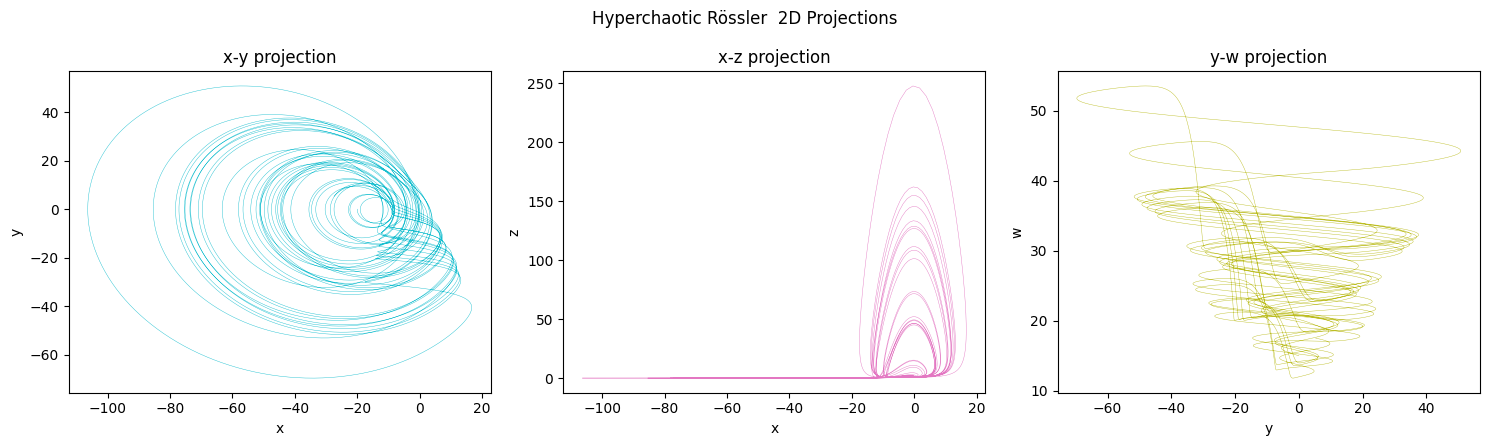

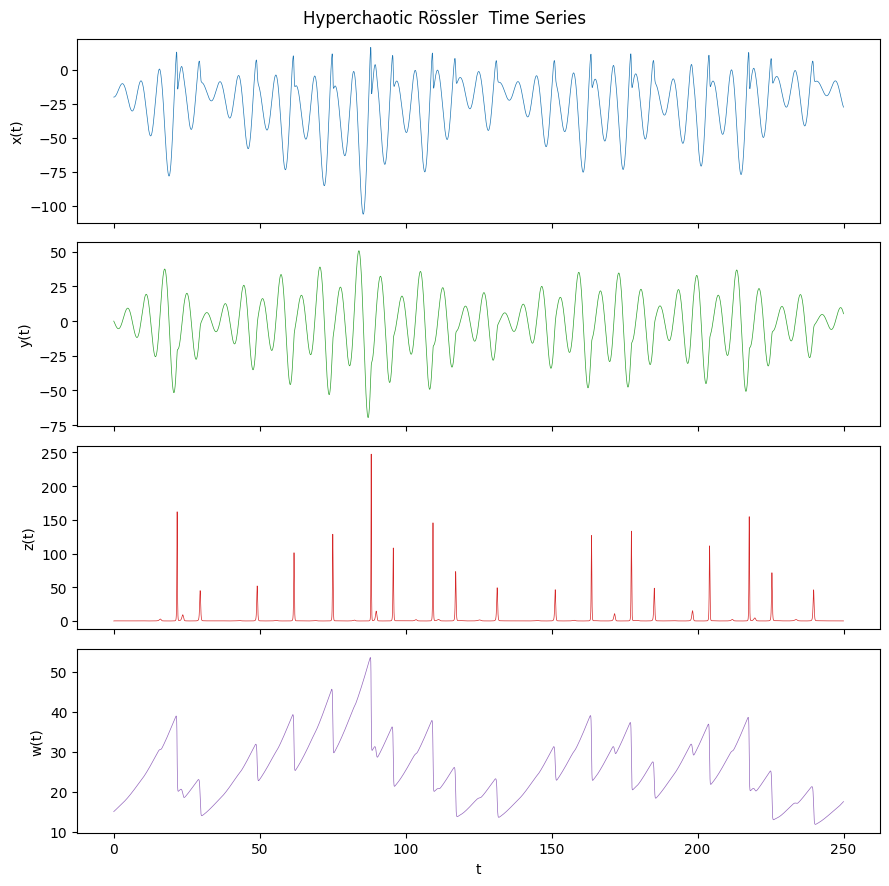

In [42]:
def hyperchaotic_rossler_rhs(s, p):
    x, y, z, w = s
    a, b, c, d = p['a'], p['b'], p['c'], p['d']
    return np.array([
        -y - z,
        x + a * y + w,
        b + x * z,
        -c * z + d * w
    ])

hr_params = dict(a=0.25, b=3.0, c=0.5, d=0.05)
t_hr, state_hr = rk4_integrate(hyperchaotic_rossler_rhs, [-20.0, 0.0, 0.0, 15.0], 0, 250, 0.01, hr_params)
xh4, yh4, zh4, wh4 = state_hr[:, 0], state_hr[:, 1], state_hr[:, 2], state_hr[:, 3]

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
axes[0].plot(xh4, yh4, lw=0.3, color='tab:cyan'); axes[0].set_xlabel('x'); axes[0].set_ylabel('y'); axes[0].set_title('x-y projection')
axes[1].plot(xh4, zh4, lw=0.3, color='tab:pink'); axes[1].set_xlabel('x'); axes[1].set_ylabel('z'); axes[1].set_title('x-z projection')
axes[2].plot(yh4, wh4, lw=0.3, color='tab:olive'); axes[2].set_xlabel('y'); axes[2].set_ylabel('w'); axes[2].set_title('y-w projection')
fig.suptitle('Hyperchaotic Rössler  2D Projections')
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(4, 1, figsize=(9, 9), sharex=True)
axes[0].plot(t_hr, xh4, lw=0.5, color='tab:blue'); axes[0].set_ylabel('x(t)')
axes[1].plot(t_hr, yh4, lw=0.5, color='tab:green'); axes[1].set_ylabel('y(t)')
axes[2].plot(t_hr, zh4, lw=0.5, color='tab:red'); axes[2].set_ylabel('z(t)')
axes[3].plot(t_hr, wh4, lw=0.5, color='tab:purple'); axes[3].set_ylabel('w(t)')
axes[3].set_xlabel('t')
fig.suptitle('Hyperchaotic Rössler  Time Series')
plt.tight_layout()
plt.show()

**Observation:** Unlike the 3-D Rössler system (one positive Lyapunov exponent), this
4-D version has **two** positive Lyapunov exponents, so the attractor stretches and folds
in two independent directions at once  visible here as the extra "thickness"/spread in
the $y$–$w$ projection compared to a single-scroll chaotic attractor.

---
# Part C  Sensitivity Analysis

## C.1 Parameter Sweep  Lorenz $\rho$ vs Local Maxima of $z(t)$

Sweep $\rho \in [0, 30]$ with $\sigma=10$, $\beta=8/3$ fixed. For each $\rho$: run the
system, discard the first 20 time units as transient, and record the local maxima of
$z(t)$.

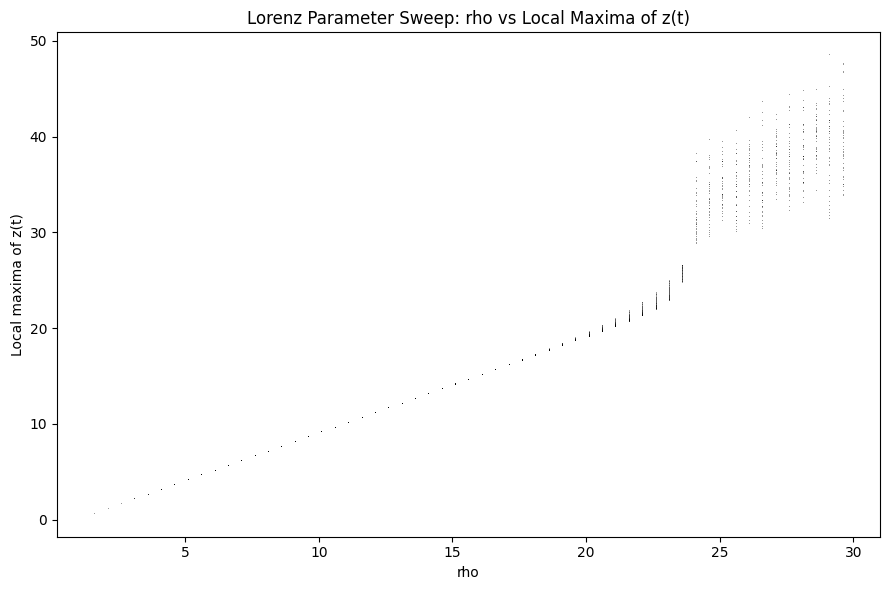

In [45]:
rho_values = np.arange(0.1, 30.01, 0.5)
sigma_fixed, beta_fixed = 10.0, 8.0/3.0
dt_sweep = 0.01
T_sweep = 50
transient_time = 20

rho_plot = []
maxima_plot = []

for rho_val in rho_values:
    params = dict(sigma=sigma_fixed, rho=rho_val, beta=beta_fixed)
    t_s, state_s = rk4_integrate(lorenz_rhs, [1.0, 1.0, 1.0], 0, T_sweep, dt_sweep, params)
    mask = t_s > transient_time
    z_s = state_s[mask, 2]
    # local maxima: point higher than both neighbours
    if len(z_s) > 2:
        is_max = (z_s[1:-1] > z_s[:-2]) & (z_s[1:-1] > z_s[2:])
        local_max_vals = z_s[1:-1][is_max]
        rho_plot.extend([rho_val] * len(local_max_vals))
        maxima_plot.extend(local_max_vals)

plt.figure(figsize=(9, 6))
plt.plot(rho_plot, maxima_plot, ',k', alpha=0.4, markersize=0.5)
plt.xlabel("rho")
plt.ylabel("Local maxima of z(t)")
plt.title("Lorenz Parameter Sweep: rho vs Local Maxima of z(t)")
plt.tight_layout()
plt.show()

**Explanation:** For small $\rho$ the system settles to a fixed point, so there are no
sustained oscillations (few/no maxima). Around $\rho\approx 24.74$ the fixed points lose
stability and the trajectory begins oscillating; beyond that the local maxima spread into
a dense band, showing the transition from stable behaviour to full chaos as $\rho\to 28$
and beyond.

## C.2 Step-size Sensitivity  Lorenz

Run Lorenz three times with $dt = 0.001, 0.01, 0.05$, same initial condition (1,1,1),
same solver (RK4), same duration ($T=50$).

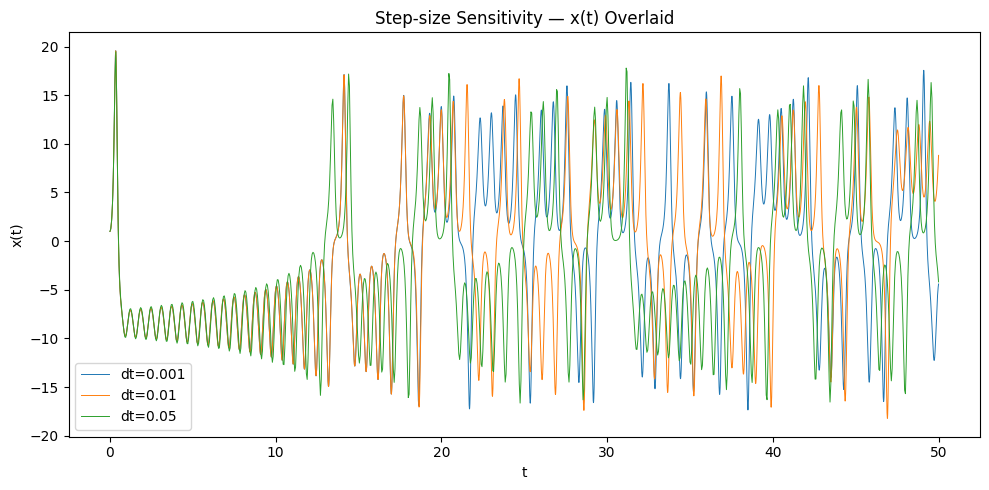

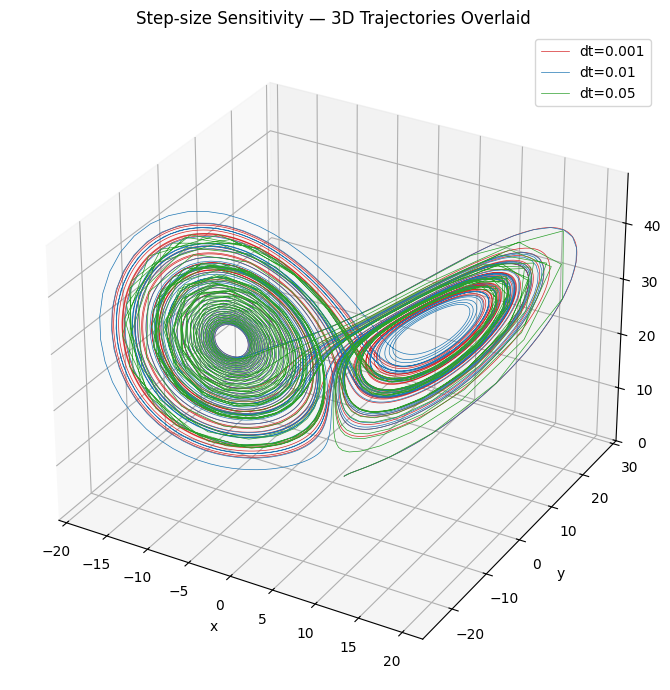

In [25]:
dt_list = [0.001, 0.01, 0.05]
T_step = 50
results = {}

for dt_val in dt_list:
    t_r, state_r = rk4_integrate(lorenz_rhs, [1.0, 1.0, 1.0], 0, T_step, dt_val, lorenz_params)
    results[dt_val] = (t_r, state_r)

plt.figure(figsize=(10, 5))
for dt_val in dt_list:
    t_r, state_r = results[dt_val]
    plt.plot(t_r, state_r[:, 0], lw=0.7, label=f"dt={dt_val}")
plt.xlabel("t")
plt.ylabel("x(t)")
plt.title("Step-size Sensitivity — x(t) Overlaid")
plt.legend()
plt.tight_layout()
plt.show()

fig = plt.figure(figsize=(8, 7))
ax = fig.add_subplot(111, projection='3d')
colors = {0.001: 'tab:red', 0.01: 'tab:blue', 0.05: 'tab:green'}
for dt_val in dt_list:
    t_r, state_r = results[dt_val]
    ax.plot(state_r[:, 0], state_r[:, 1], state_r[:, 2], lw=0.5,
            color=colors[dt_val], label=f"dt={dt_val}")
ax.set_xlabel('x'); ax.set_ylabel('y'); ax.set_zlabel('z')
ax.set_title('Step-size Sensitivity — 3D Trajectories Overlaid')
ax.legend()
plt.tight_layout()
plt.show()

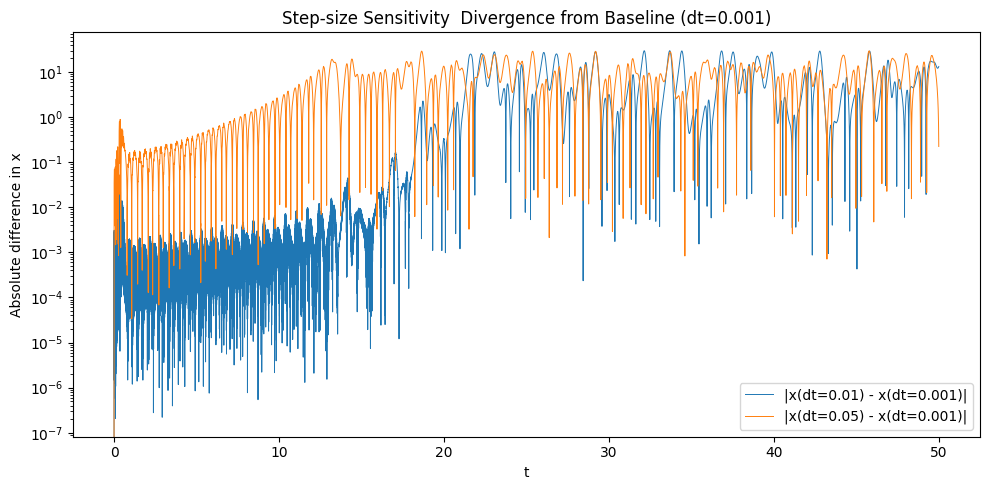

In [34]:
# Baseline = smallest dt most accurate
baseline_dt = min(dt_list)
t_base, state_base = results[baseline_dt]
x_base = state_base[:, 0]

plt.figure(figsize=(10, 5))
for dt_val in dt_list:
    if dt_val == baseline_dt:
        continue
    t_r, state_r = results[dt_val]
    x_interp = np.interp(t_base, t_r, state_r[:, 0])
    diff = np.abs(x_interp - x_base)
    plt.plot(t_base, diff, lw=0.7, label=f"|x(dt={dt_val}) - x(dt={baseline_dt})|")

plt.xlabel("t")
plt.ylabel("Absolute difference in x")
plt.title("Step-size Sensitivity  Divergence from Baseline (dt=0.001)")
plt.yscale('log')
plt.legend()
plt.tight_layout()
plt.show()

**Why the results start to diverge:** the Lorenz system is chaotic, meaning nearby
trajectories separate exponentially fast (sensitive dependence on initial conditions).
Numerical integration error introduced by a larger step size acts like a tiny perturbation
at every step; in a non-chaotic system this error would stay small, but here it is
amplified exponentially, so the coarser-dt trajectories visibly peel away from the
baseline after only a few Lyapunov times.

**Which dt is best:** $dt=0.001$ gives the most accurate trajectory (closest to the true
solution) but is the most computationally expensive. $dt=0.01$ is a reasonable practical
trade-off  the qualitative attractor shape and short-term trajectory are still well
resolved, and it is what most of this notebook uses. $dt=0.05$ is too coarse for RK4 on
this system: the trajectory diverges from the baseline quickly and can occasionally
become numerically unstable.

---
# Conclusion

**Discrete vs Continuous Chaos:** Discrete systems (Logistic, Hénon) evolve in fixed
iteration steps with no notion of "time between steps," and chaos is analyzed directly
through the map's iterates and bifurcation diagrams over a control parameter. Continuous
systems (Lorenz, Rössler, Chen) evolve via differential equations integrated with a
numerical solver (RK4 here), so the *choice of step size* itself becomes a source of
numerical sensitivity  a concern that simply doesn't exist for discrete maps.

**Chaotic vs Hyperchaotic Systems:** A standard chaotic system (e.g. Lorenz, Rössler,
Chen) has exactly one positive Lyapunov exponent  trajectories stretch and fold in a
single direction, producing a single-scroll or double-scroll attractor. A hyperchaotic
system (e.g. the 4-D Rössler) has *two or more* positive Lyapunov exponents, so
stretching/folding happens in multiple independent directions simultaneously, producing
richer, higher-dimensional, and generally harder-to-predict dynamics than ordinary chaos.
